In [11]:
import zipfile


zip_path = 'Archive.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset_xray')

print("Dataset Unzipped Successfully!")

Dataset Unzipped Successfully!


In [8]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


base_path = 'dataset_xray'
if 'chest_xray' in os.listdir(base_path):
    base_path = os.path.join(base_path, 'chest_xray')

train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'val')
test_dir = os.path.join(base_path, 'test')


IMG_SIZE = (150, 150)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
from tensorflow.keras import layers, models


model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Training (10 epochs)
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.7696 - loss: 0.4914 - val_accuracy: 0.8750 - val_loss: 0.5145
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.8905 - loss: 0.2644 - val_accuracy: 0.6875 - val_loss: 0.8519
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9080 - loss: 0.2205 - val_accuracy: 0.7500 - val_loss: 0.8506
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9059 - loss: 0.2245 - val_accuracy: 0.8125 - val_loss: 0.5847
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.9298 - loss: 0.1847 - val_accuracy: 0.5000 - val_loss: 1.3130
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9222 - loss: 0.1908 - val_accuracy: 0.6250 - val_loss: 0.9317
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.9273 - loss: 0.1884 - val_accuracy: 0.6875 - val_loss: 1.2316
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9327 - loss: 0.1773 - val_accu

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 793ms/step - accuracy: 0.8846 - loss: 0.3433

Test Accuracy: 88.46%


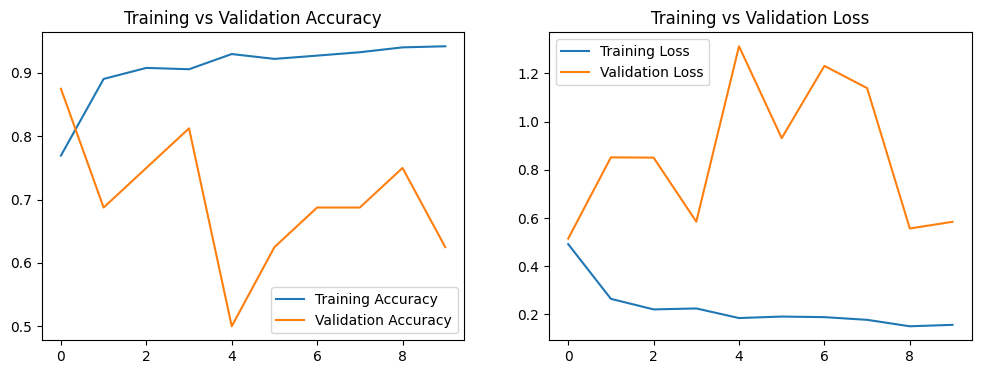

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 713ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      NORMAL       0.97      0.72      0.82       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.85      0.87       624
weighted avg       0.90      0.88      0.88       624



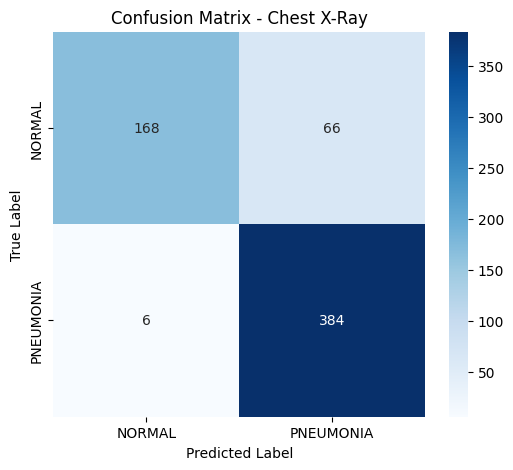

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Test Dataset Evaluation
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# 2. Accuracy & Loss Visualization
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# 3. Predictions & Confusion Matrix
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Chest X-Ray')
plt.show()